In [1]:
import pandas as pd

train_df = pd.read_csv("UNSW_NB15_training-set.csv")
test_df = pd.read_csv("UNSW_NB15_testing-set.csv")

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (175341, 45)
Test: (82332, 45)


In [2]:
df = pd.concat([train_df, test_df], axis=0)

print("Total Shape:", df.shape)
df.head()

Total Shape: (257673, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [3]:
df = pd.concat([train_df, test_df], axis=0)

print("Total Shape:", df.shape)
df.head()

Total Shape: (257673, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257673 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 257673 non-null  int64  
 1   dur                257673 non-null  float64
 2   proto              257673 non-null  object 
 3   service            257673 non-null  object 
 4   state              257673 non-null  object 
 5   spkts              257673 non-null  int64  
 6   dpkts              257673 non-null  int64  
 7   sbytes             257673 non-null  int64  
 8   dbytes             257673 non-null  int64  
 9   rate               257673 non-null  float64
 10  sttl               257673 non-null  int64  
 11  dttl               257673 non-null  int64  
 12  sload              257673 non-null  float64
 13  dload              257673 non-null  float64
 14  sloss              257673 non-null  int64  
 15  dloss              257673 non-null  int64  
 16  sinpkt  

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['proto', 'service', 'state']:
    df[col] = le.fit_transform(df[col])

In [6]:
X = df.drop(['label', 'attack_cat'], axis=1)
y = df['label']

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [10]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/15
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9105 - loss: 0.1842 - val_accuracy: 0.9324 - val_loss: 0.1392
Epoch 2/15
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9319 - loss: 0.1429 - val_accuracy: 0.9387 - val_loss: 0.1308
Epoch 3/15
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9382 - loss: 0.1328 - val_accuracy: 0.9455 - val_loss: 0.1224
Epoch 4/15
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9410 - loss: 0.1273 - val_accuracy: 0.9433 - val_loss: 0.1238
Epoch 5/15
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9436 - loss: 0.1240 - val_accuracy: 0.9466 - val_loss: 0.1168
Epoch 6/15
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9454 - loss: 0.1208 - val_accuracy: 0.9483 - val_loss: 0.1149
Epoch 7/15
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9465 - loss: 0.1180 - val_accuracy: 0.9494 - val_loss: 0.1122
Epoch 8/15
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9473 - loss: 0.1163 

In [13]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

1611/1611 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9602 - loss: 0.0887
Accuracy: 0.9602406024932861


1611/1611 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


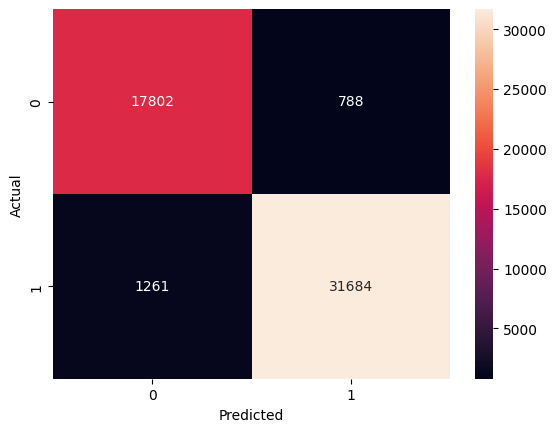

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

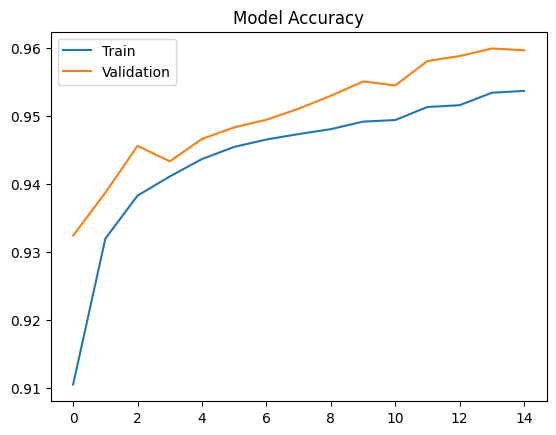

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [16]:
import numpy as np

X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1],1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    LSTM(64),

    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [19]:
history = model.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 72s 25ms/step - accuracy: 0.9241 - loss: 0.1683 - val_accuracy: 0.9421 - val_loss: 0.1339
Epoch 2/10
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 61s 23ms/step - accuracy: 0.9536 - loss: 0.1077 - val_accuracy: 0.9618 - val_loss: 0.0881
Epoch 3/10
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 64s 25ms/step - accuracy: 0.9618 - loss: 0.0899 - val_accuracy: 0.9629 - val_loss: 0.0874
Epoch 4/10
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 67s 26ms/step - accuracy: 0.9646 - loss: 0.0831 - val_accuracy: 0.9671 - val_loss: 0.0798
Epoch 5/10
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 59s 23ms/step - accuracy: 0.9668 - loss: 0.0779 - val_accuracy: 0.9691 - val_loss: 0.0744
Epoch 6/10
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 81s 23ms/step - accuracy: 0.9684 - loss: 0.0748 - val_accuracy: 0.9705 - val_loss: 0.0717
Epoch 7/10
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 82s 23ms/step - accuracy: 0.9696 - loss: 0.0718 - val_accuracy: 0.9657 - val_loss: 0.0788
Epoch 8/10
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 59s 23ms/step - accuracy: 0.9703 -

In [20]:
loss, acc = model.evaluate(X_test_cnn, y_test)
print("CNN+LSTM Accuracy:", acc)

1611/1611 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9726 - loss: 0.0636
CNN+LSTM Accuracy: 0.9726011157035828
